#Поиск ассоциативных правил

Разработайте программу, которая выполняет классификацию заданного набора данных с помощью дерева решений. Параметрами программы являются набор данных, критерий выбора атрибута разбиения (Information gain, Gain ratio, Gini index).

Проведите эксперименты на наборе Census Income (данные о результатах переписи населения, в т.ч. о годовом доходе -- ниже или выше $50000: скачать обучающую выборку в формате CSV, тестовую выборку в формате CSV, скачать описание). В качестве обучающей выборки для построения дерева используйте 100% исходных данных.

Выполните визуализацию построенных деревьев решений.

Доработайте программу, добавив в список ее параметров долю, которую занимает обучающая выборка от общего размера набора данных, и обеспечив вычисление и выдачу в качестве результатов следующих показателей качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера. Проведите эксперименты на наборе данных, фиксируя критерий выбора атрибута разбиения и варьируя соотношение мощностей обучающей и тестовой выборок от 60%:40% до 90%:10% с шагом 10%.

Выполните визуализацию полученных результатов в виде следующих диаграмм:

построенные деревья решений для заданного набора данных;
показатели качества классификации в зависимости от соотношения мощностей обучающей и тестовой выборок для заданного набора данных.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, ADASYN

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import graphviz

In [ ]:
train_df = pd.read_csv("train.csv", header=None, na_values=[" ?"])
test_df = pd.read_csv("test.csv", header=None, na_values=" ?")
train_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
columns = [
    "age", "workclass", "fnlwgt", "education",
    "education_num", "marital_status", "occupation", "relationship",
    "race", "sex", "capital_gain","capital_loss", "hours_per_week", "native_country", "income"
]

train_df.columns = columns
test_df.columns = columns

test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

df = pd.concat([train_df, test_df])
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
16277,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [ ]:
for col in df.columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

train_df = df.iloc[:len(train_df)]
test_df = df.iloc[len(train_df):]

X_train, y_train = train_df.drop(columns=["income"]), train_df["income"]
X_test, y_test = test_df.drop(columns=["income"]), test_df["income"]
X_train

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,3,257302,7,12,2,12,5,4,0,0,0,38,38
32557,40,3,154374,11,9,2,6,0,4,1,0,0,40,38
32558,58,3,151910,11,9,6,0,4,4,0,0,0,40,38
32559,22,3,201490,11,9,4,0,3,4,1,0,0,20,38


Критерий: gini
Accuracy: 0.8089
Precision: 0.5925
Recall: 0.6113
F1 score: 0.6017


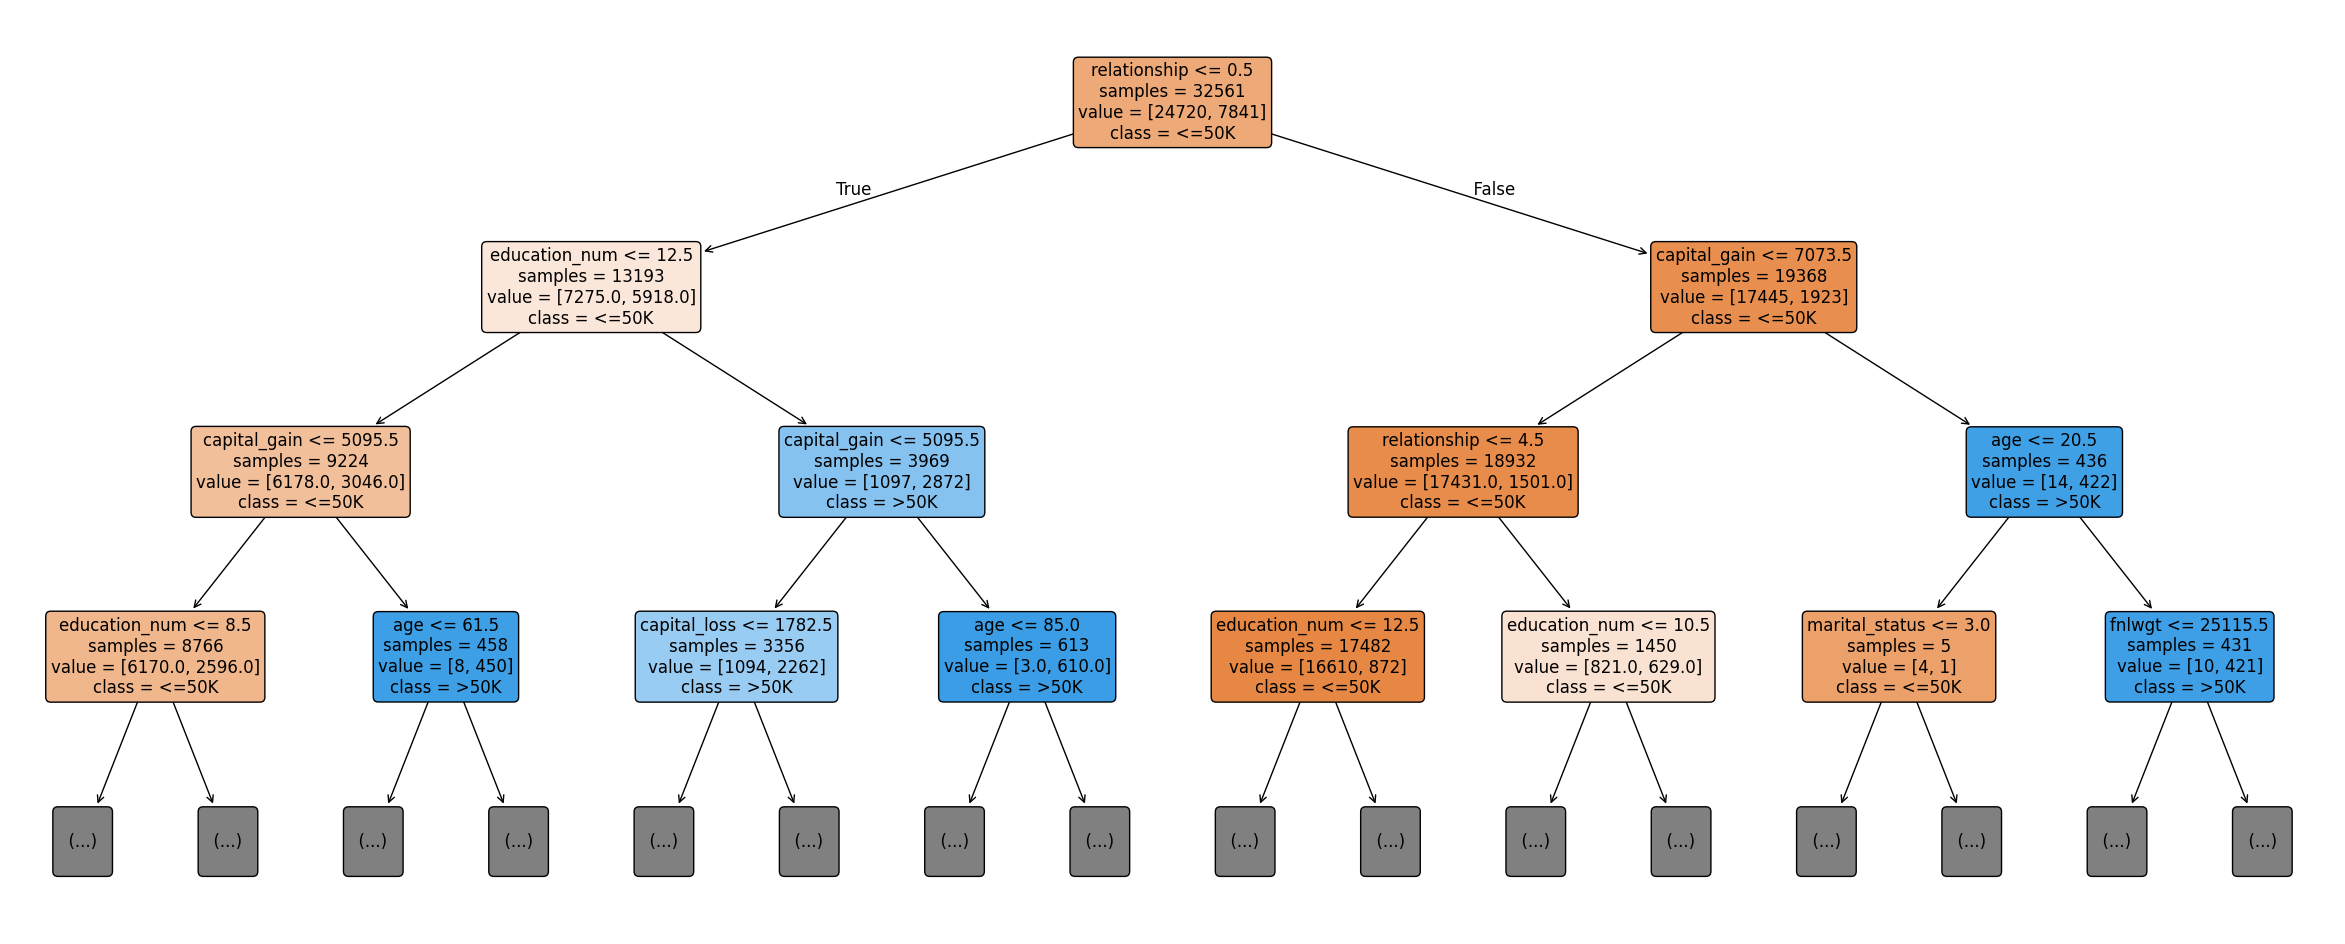

Критерий: entropy
Accuracy: 0.8093
Precision: 0.5962
Recall: 0.5980
F1 score: 0.5971


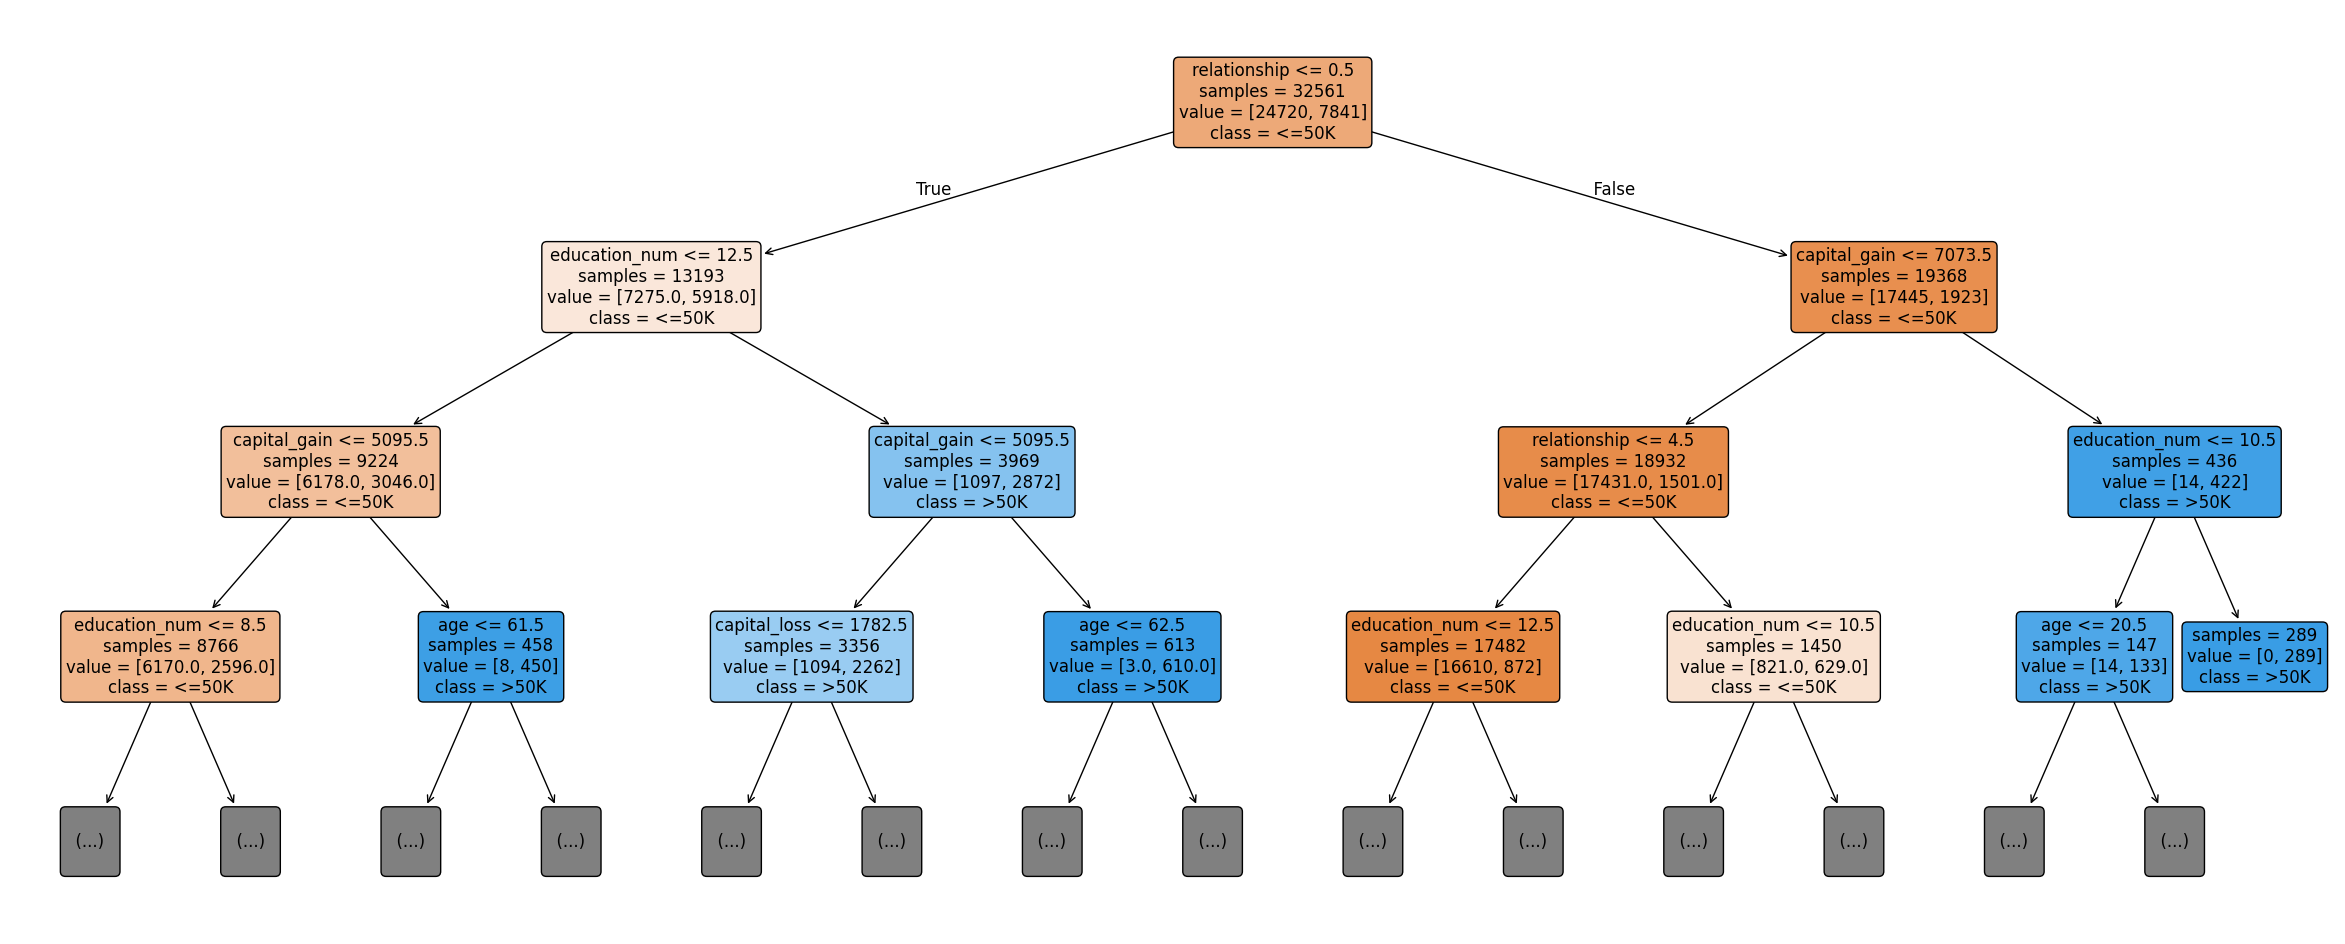

In [ ]:
def train_decision_tree(criterion="gini"):
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Критерий: {criterion}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 score: {f1:.4f}")

    plt.figure(figsize=(30, 12))
    plot_tree(model, feature_names=X_train.columns, class_names=["<=50K", ">50K"],
              filled=True,
              rounded=True,
              max_depth=3,
              fontsize=12,
              impurity=False,
              proportion=False)
    plt.show()

for criterion in ["gini", "entropy"]:
    train_decision_tree(criterion)

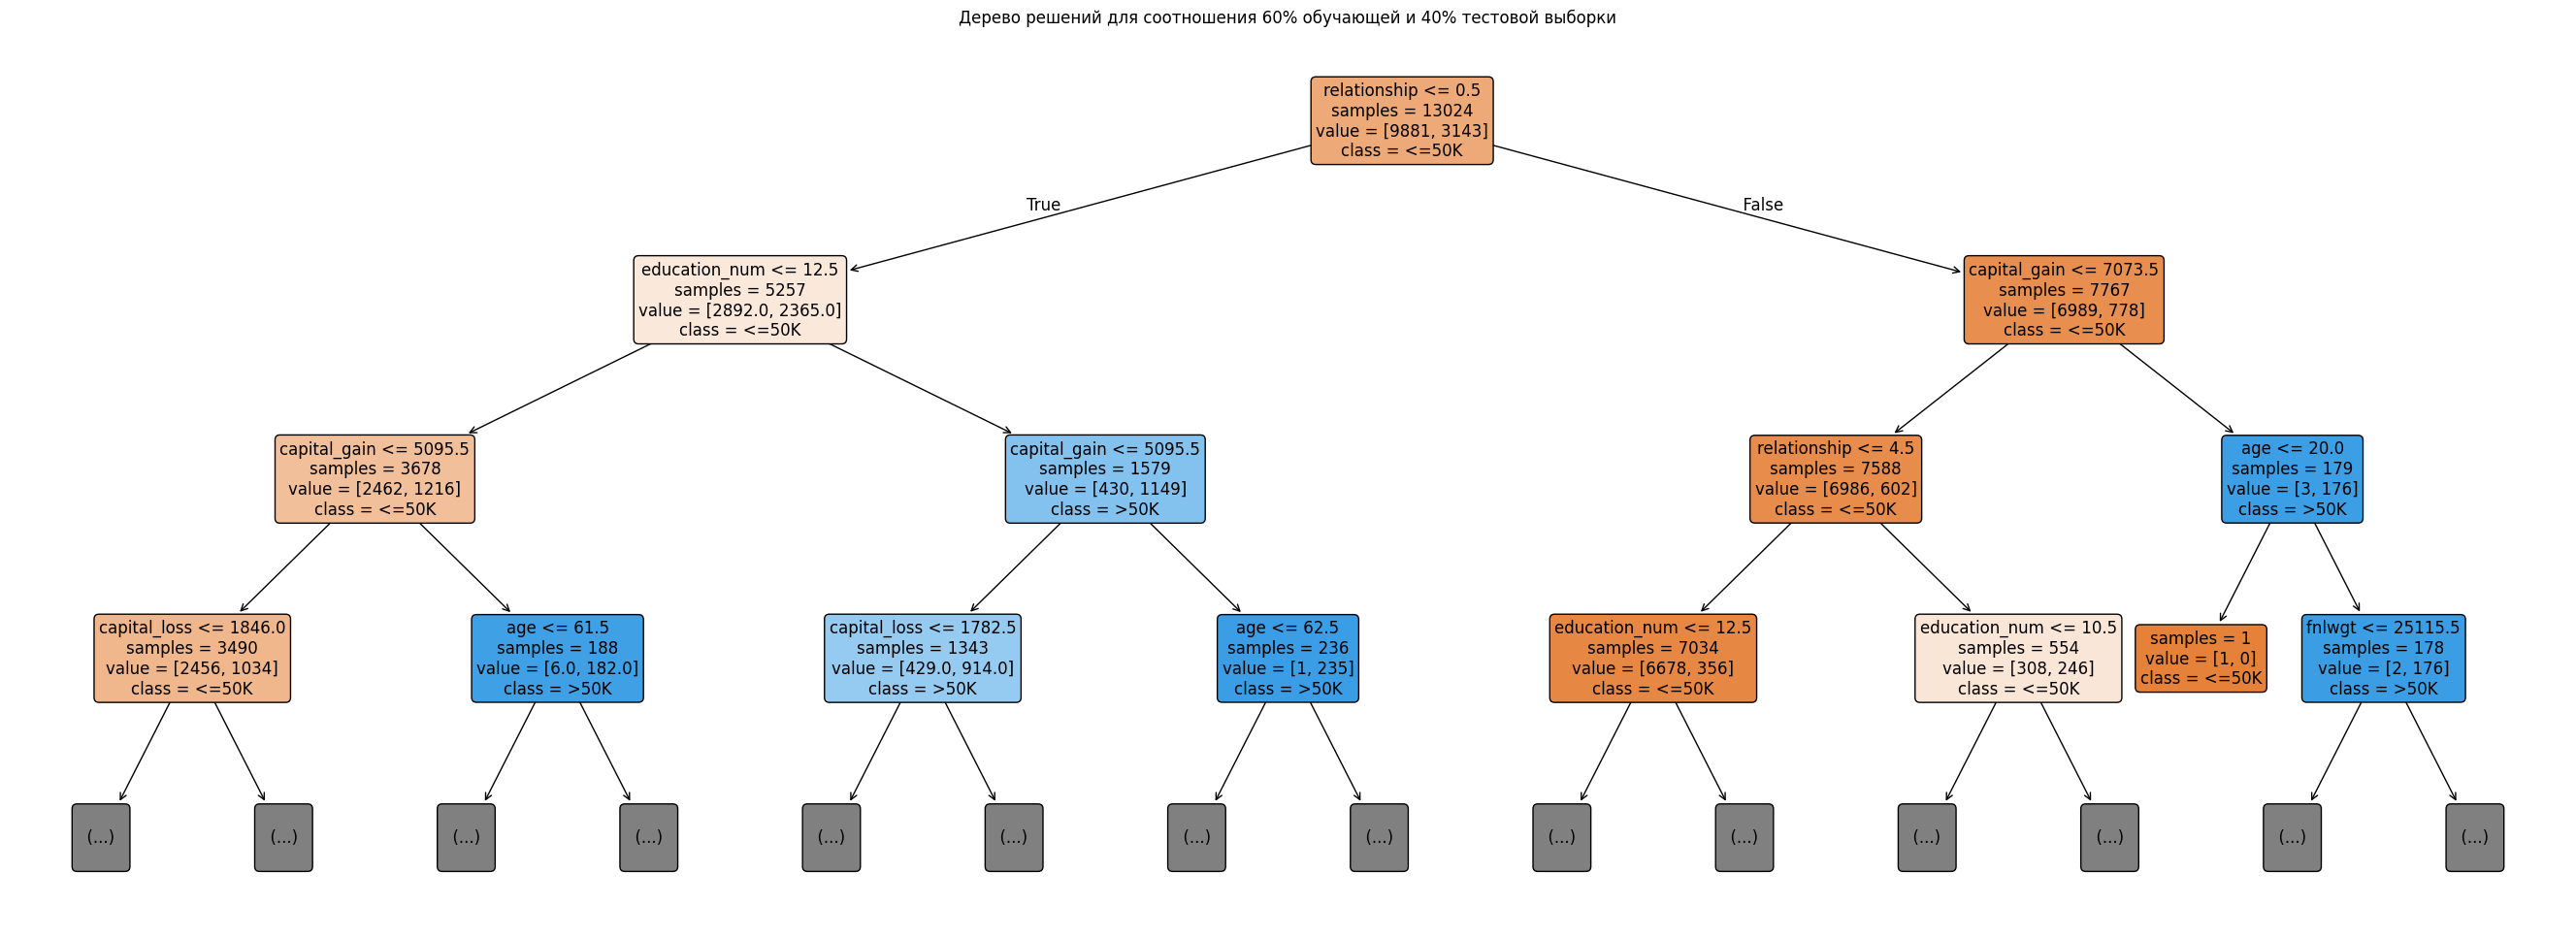

Соотношение 60% обучающей, 40% тестовой выборки:
  Accuracy: 0.8119
  Precision: 0.6050
  Recall: 0.6275
  F1 score: 0.6160


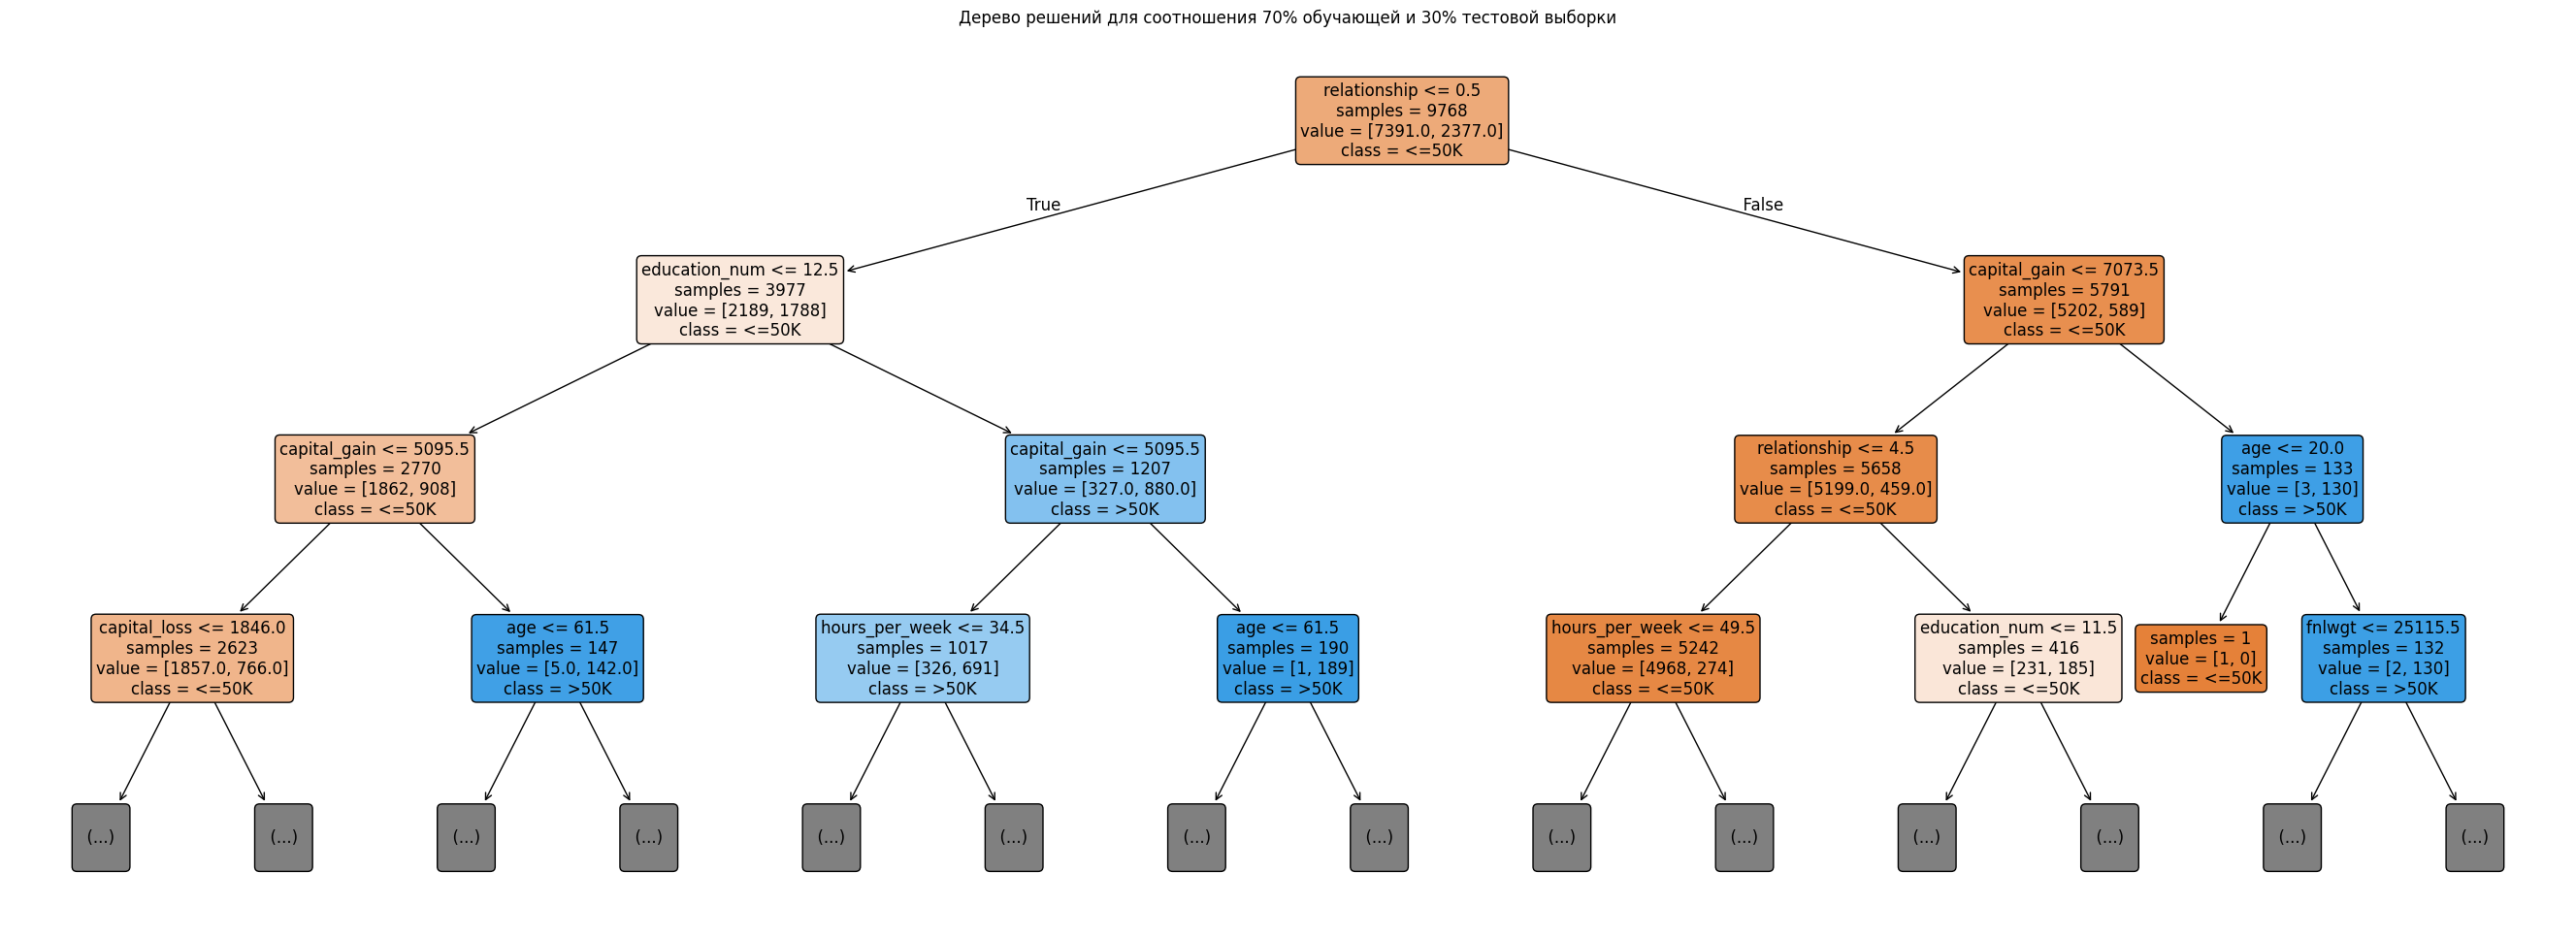

Соотношение 70% обучающей, 30% тестовой выборки:
  Accuracy: 0.8049
  Precision: 0.5909
  Recall: 0.6049
  F1 score: 0.5978


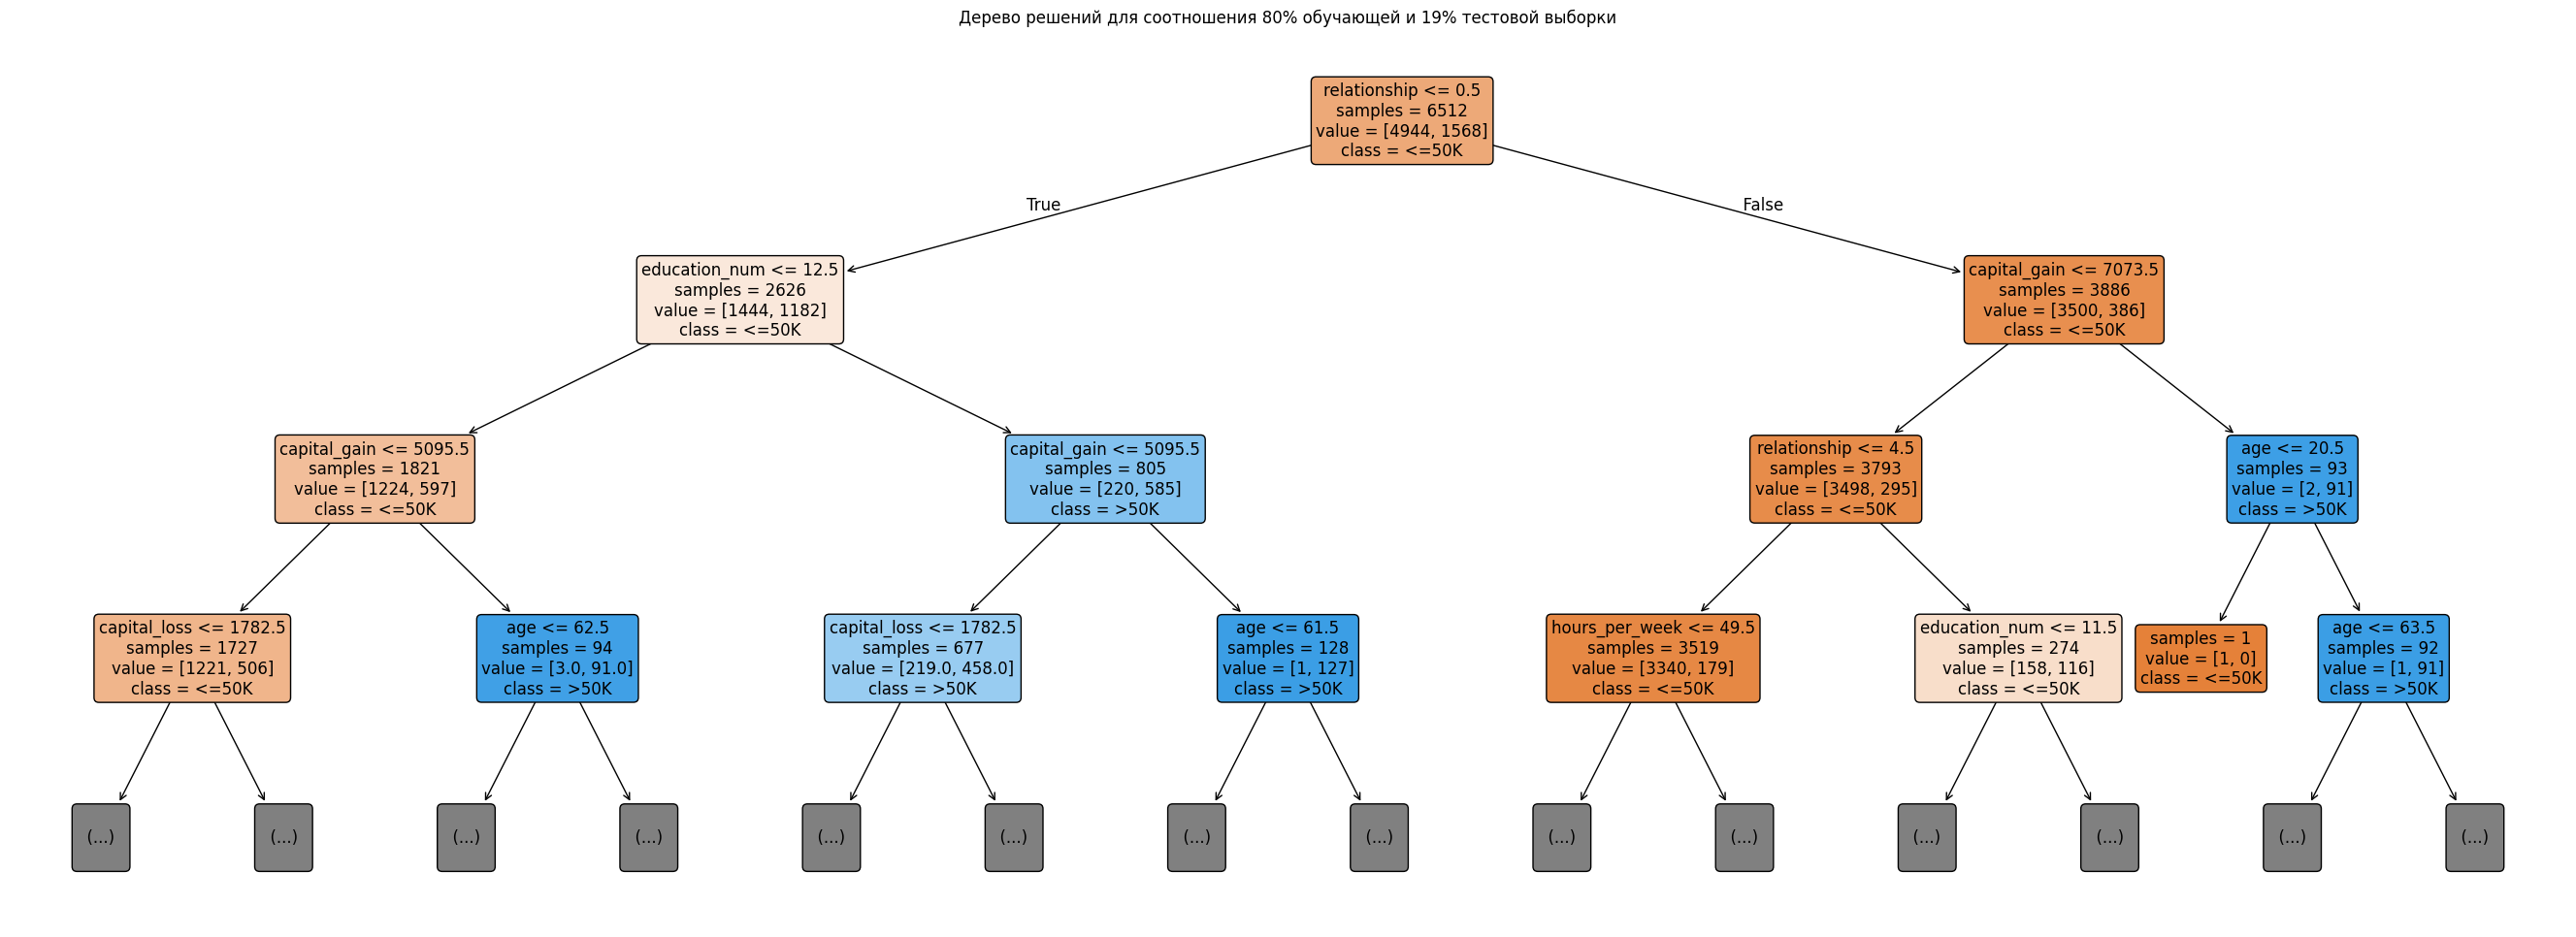

Соотношение 80% обучающей, 19% тестовой выборки:
  Accuracy: 0.8031
  Precision: 0.5899
  Recall: 0.5988
  F1 score: 0.5943


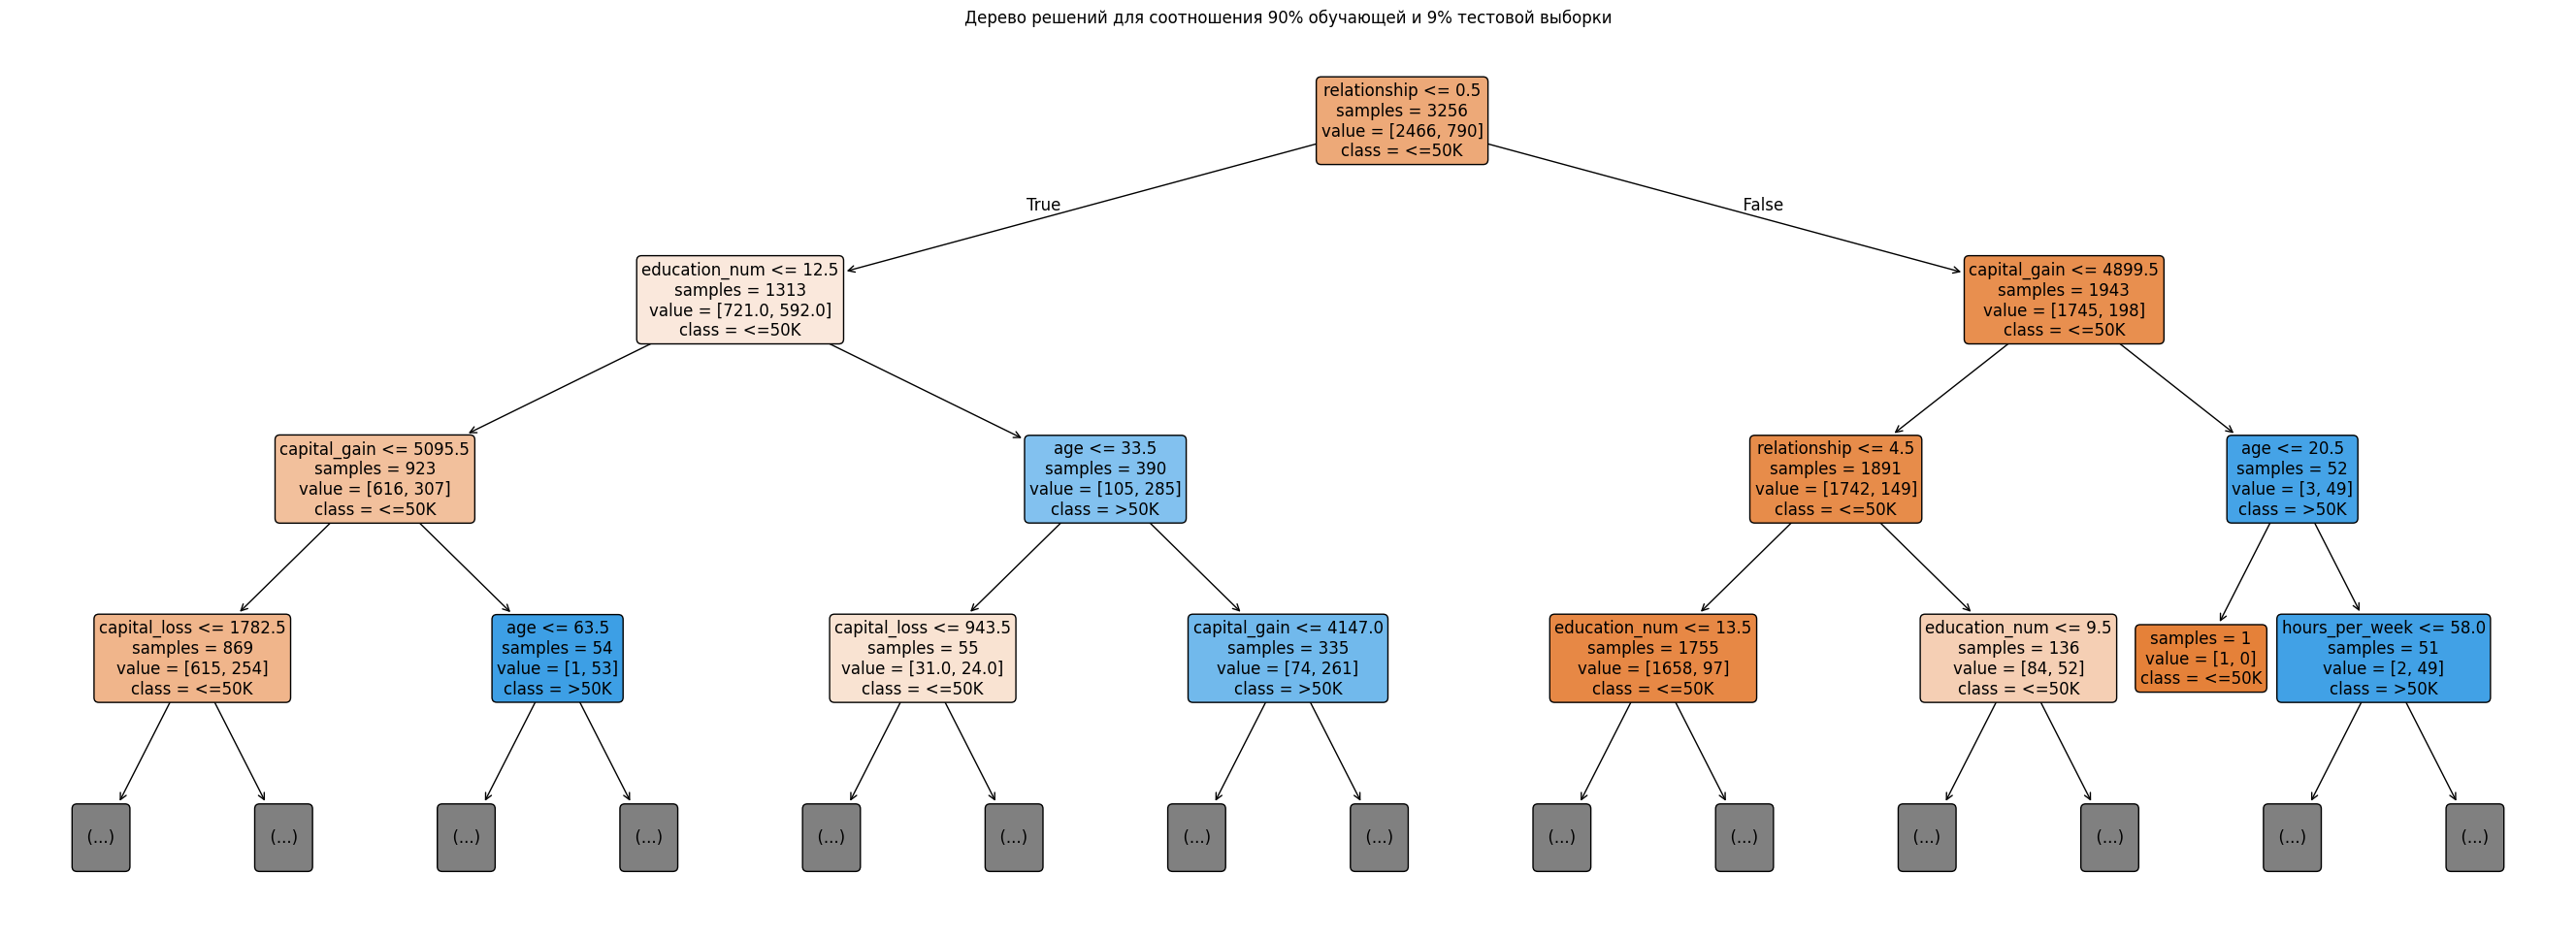

Соотношение 90% обучающей, 9% тестовой выборки:
  Accuracy: 0.8009
  Precision: 0.5848
  Recall: 0.5951
  F1 score: 0.5899


In [ ]:
ratios = [0.6, 0.7, 0.8, 0.9]
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1_score": []
}

for ratio in ratios:
    X_train_part, X_test_part, y_train_part, y_test_part = train_test_split(X_train, y_train, train_size=1-ratio, random_state=42)

    model = DecisionTreeClassifier(criterion="gini", random_state=42)
    model.fit(X_train_part, y_train_part)

    plt.figure(figsize=(34, 12))
    plot_tree(model, feature_names=X_train.columns,
              class_names=["<=50K", ">50K"],
              filled=True,
              rounded=True,
              max_depth=3,
              fontsize=12,
              impurity=False,
              proportion=False)
    plt.title(f"Дерево решений для соотношения {int(ratio*100)}% обучающей и {int((1-ratio)*100)}% тестовой выборки")
    plt.show()

    y_pred = model.predict(X_test_part)

    accuracy = accuracy_score(y_test_part, y_pred)
    precision = precision_score(y_test_part, y_pred)
    recall = recall_score(y_test_part, y_pred)
    f1 = f1_score(y_test_part, y_pred)

    metrics["accuracy"].append(accuracy)
    metrics["precision"].append(precision)
    metrics["recall"].append(recall)
    metrics["f1_score"].append(f1)

    print(f"Соотношение {int(ratio*100)}% обучающей, {int((1-ratio)*100)}% тестовой выборки:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 score: {f1:.4f}")

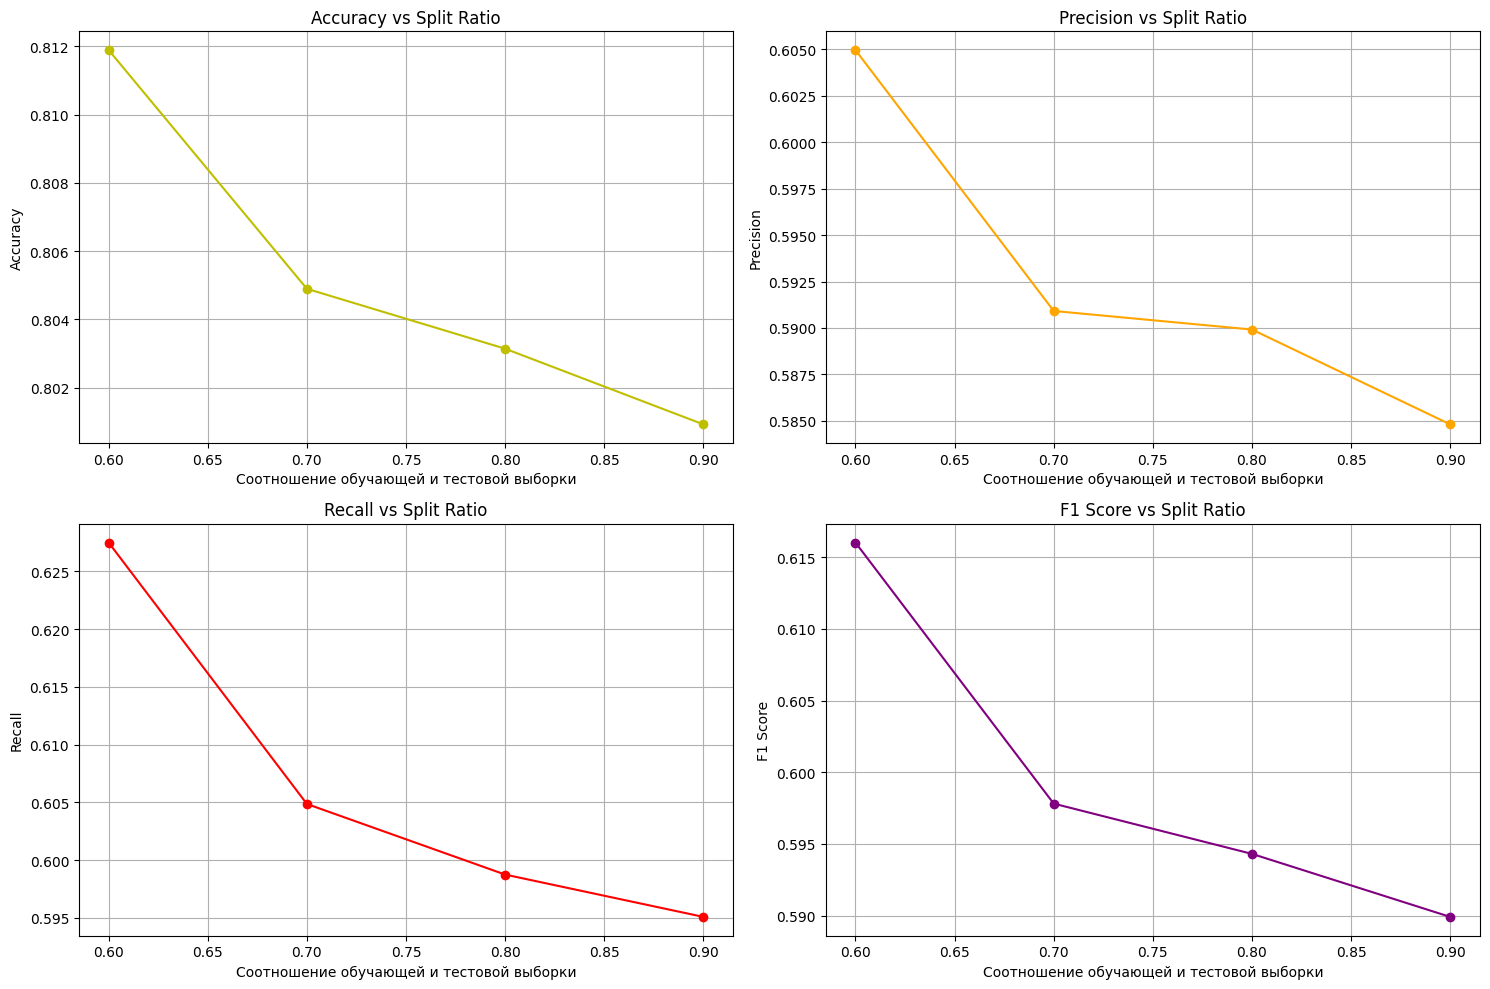

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0].plot(ratios, metrics["accuracy"], marker="o", color="y", label="Accuracy")
ax[0, 0].set_title("Accuracy vs Split Ratio")
ax[0, 0].set_xlabel("Соотношение обучающей и тестовой выборки")
ax[0, 0].set_ylabel("Accuracy")
ax[0, 0].grid(True)

ax[0, 1].plot(ratios, metrics["precision"], marker="o", color="orange", label="Precision")
ax[0, 1].set_title("Precision vs Split Ratio")
ax[0, 1].set_xlabel("Соотношение обучающей и тестовой выборки")
ax[0, 1].set_ylabel("Precision")
ax[0, 1].grid(True)

ax[1, 0].plot(ratios, metrics["recall"], marker="o", color="r", label="Recall")
ax[1, 0].set_title("Recall vs Split Ratio")
ax[1, 0].set_xlabel("Соотношение обучающей и тестовой выборки")
ax[1, 0].set_ylabel("Recall")
ax[1, 0].grid(True)

ax[1, 1].plot(ratios, metrics["f1_score"], marker="o", color="purple", label="F1 Score")
ax[1, 1].set_title("F1 Score vs Split Ratio")
ax[1, 1].set_xlabel("Соотношение обучающей и тестовой выборки")
ax[1, 1].set_ylabel("F1 Score")
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()